In [ ]:
!pip install gensim
!pip install -U pip setuptools wheel
!pip install -U spacy
!spacy download en_core_web_lg
!pip install natasha

# English preprocessing

In [ ]:
import re
import gensim
import glob
import en_core_web_lg
import tqdm

/usr/local/lib/python3.8/dist-packages/torch/cuda/__init__.py:497: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [ ]:
#This code is for decontracting shortened words (won't -> will not)
def decontracted(phrase):
    # specific
    phrase = re.sub(r"won['’‘`]t", "will not", phrase)
    phrase = re.sub(r"can['’‘`]t", "can not", phrase)
    phrase = re.sub(r"ain['’‘`]t", "am not", phrase)

    # general
    phrase = re.sub(r"n['’‘`]t", " not", phrase)
    phrase = re.sub(r"['’‘`]re", " are", phrase)
    phrase = re.sub(r"['’‘`]s", " is", phrase)
    phrase = re.sub(r"['’‘`]d", " would", phrase)
    phrase = re.sub(r"['’‘`]ll", " will", phrase)
    phrase = re.sub(r"['’‘`]t", " not", phrase)
    phrase = re.sub(r"['’‘`]ve", " have", phrase)
    phrase = re.sub(r"['’‘`]m", " am", phrase)

    #phrase = re.sub('([.;!?])', r' \1 ', phrase)
    phrase = re.sub(r'[^\w.?!;]', ' ', phrase)
    phrase = re.sub(' +', ' ', phrase)
    sentences = re.split('([.;!?] *)', phrase)

    return ' '.join([i.capitalize() for i in  sentences])

The function below is for preprocessing an English text

In [ ]:
def prepare_english_text(input_file, output_file):
    '''
    input_file - it is path to the EXISTING txt file. It shuold contain
    raw text in English

    output_file - it is path to txt file, where the preprocessed text will be written

    '''
    nlp = en_core_web_lg.load(disable=['parser'])
    nlp.max_length = 5000000
    #We will replace PROPN, PRON and NUM with tokens
    #(proper nouns, pronouns and numericals)
    pos_dict = {'PROPN': 'person1', 'PRON': 'pron1', 'NUM': 'ordinal1'}
    fin  = open(input_file, 'r')
    with open(output_file, 'w') as prepared_text:
      for line in fin:
        #decontract text
        preprocessed_text = decontracted(line.strip())
        #apply nlp model to get lemmas and pos
        nlp_doc = nlp(preprocessed_text)
        for token in nlp_doc:
              #if the pos of the word is PROPN, PRON or NUM
              #we replace it with the token
              if token.pos_ in pos_dict:
                    prepared_text.write(pos_dict[token.pos_])
                    prepared_text.write(' ')
              #if the word is a number, we replace it with token
              elif token.lemma_.isdigit():
                    prepared_text.write('ordinal1')
                    prepared_text.write(' ')
              #we skip punktuation
              elif token.pos_ != 'PUNCT':
                    #we replace word with its lemma
                    prepared_text.write(token.lemma_.lower())
                    prepared_text.write(' ')
        prepared_text.write('\n')

Example of spaCy model's work:


In [ ]:
#Creating the model
nlp = en_core_web_lg.load(disable=['parser'])
nlp.max_length = 5000000

Let's work with simple sentence 'She loves her husband John'

In [ ]:
nlp_doc = nlp('She loves her husband John')

Let's print lemma and PoS for every word in the sentence

In [ ]:
for token in nlp_doc:
  print(token.lemma_, token.pos_)

she PRON
love VERB
her PRON
husband NOUN
John PROPN


$⇑$ token.lemma\_ contains lemma of the word,  token.pos\_ contains part of speech

So, let's check, how the prepare_english_text function works:

Let's create some txt file (flame.txt)

In [ ]:
%%writefile /content/flame.txt
She loves her husband John
What will we do with a drunken sailor?

Writing /content/flame.txt


We can see, that flame.txt file exists:

In [ ]:
!ls

flame.txt  sample_data


In [ ]:
prepare_english_text('/content/flame.txt', '/content/zzzzzzz.txt')

We can see, that zzzzzzz.txt file is created:

In [ ]:
!ls

flame.txt  sample_data	zzzzzzz.txt


And the preprocessed text is written in it:

In [ ]:
!cat /content/zzzzzzz.txt

pron1 love pron1 husband person1 
pron1 will pron1 do with a drunken sailor 


So, now you can connect your Google Drive to the notebook and apply prepare_english_text to your text. Just put the path to it as first argument and path to new file you want to create as second argument

But if I have a lot of text in a folder and want to have preprocessed text in anotnother folder? And the texts shoul have similar names?

In [ ]:
def prepare_english_texts_from_folder(input_folder, output_folder):
  files = sorted(glob.glob(input_folder + '/*'))
  for file in tqdm.tqdm(files):
    output_file = output_folder + '/PREPROCESSED_' + file.split('/')[-1]
    prepare_english_text(file, output_file)

The example:

In [ ]:
%%writefile /content/Yesterday.txt
Yesterday
All my troubles seemed so far away
Now it looks as though they're here to stay
Oh, I believe in yesterday

Writing /content/Yesterday.txt


In [ ]:
!mkdir raw_texts
!mv Yesterday.txt raw_texts
!mv flame.txt raw_texts

In [ ]:
!ls raw_texts

flame.txt  Yesterday.txt


In [ ]:
!mkdir preprocessed_texts

In [ ]:
!ls

preprocessed_texts  raw_texts  sample_data  zzzzzzz.txt


Now, we have 'raw_texts' folder with raw texts and empty 'preprocessed_texts' folder.

In [ ]:
import glob
prepare_english_texts_from_folder('raw_texts', 'preprocessed_texts' )

100%|██████████| 2/2 [00:12<00:00,  6.10s/it]


In [ ]:
!ls preprocessed_texts

PREPROCESSED_flame.txt	PREPROCESSED_Yesterday.txt


In [ ]:
!cat preprocessed_texts/PREPROCESSED_flame.txt

pron1 love pron1 husband person1 
pron1 will pron1 do with a drunken sailor 


In [ ]:
!cat preprocessed_texts/PREPROCESSED_Yesterday.txt

yesterday 
all pron1 trouble seem so far away 
now pron1 look as though pron1 be here to stay 
oh pron1 believe in yesterday 


So, we have 2 text in the 'preprocessed_texts'  folder and the name of every text is 'PREPROCESSED_' + name of the initial file.


Note: if you dislike the new name of the files, you can the way it is created in the function

**Conclusion** All in all, the code above can help you to preprocess texts (a particular text or text from a folder) in English

# Russian preprocessing

In [ ]:
def poem(text):
    lines = text.split('\n')
    if len(lines):
        not_poem_probability = sum([line[0].islower() for line in lines  if line]) / len(lines)
        return not_poem_probability < 0.3
    return False

In [ ]:
from natasha import (
    Segmenter, MorphVocab,
    NewsNERTagger,
    NewsEmbedding,
    NewsMorphTagger,
    Doc
)
import re
import glob
import tqdm

In [ ]:

def prepare_russian_text(input_file, output_file):

    segmenter = Segmenter()
    emb = NewsEmbedding()
    morph_tagger = NewsMorphTagger(emb)
    ner_tagger = NewsNERTagger(emb)
    morph_vocab = MorphVocab()

    label_dict = {'NUM': '0', 'PRON': '1', 'PER': '2', 'LOC': '3', 'ORG': '4'}
    next_label_num = 5



    with open(input_file) as fin:
      raw_text = ' '.join(fin.readlines()).replace('\n', ' ')



    raw_text = re.sub(r'\d+', '0' , raw_text)


    doc = Doc(raw_text)
    doc.segment(segmenter)
    doc.tag_ner(ner_tagger)

    for span in reversed(doc.ner.spans):
        if span.type not in label_dict:
            label_dict[span.type] = str(next_label_num)
            next_label_num += 1
        raw_text = "".join((raw_text[:span.start], label_dict[span.type], raw_text[span.stop:]))



    doc = Doc(raw_text)
    doc.segment(segmenter)
    doc.tag_morph(morph_tagger)



    prepared_text = ''
    prev_num = False
    for token in doc.tokens:

        if token.pos == 'NUM' and not token.text.isdigit():
            if not prev_num:
                prepared_text += '0'
                prepared_text += ' '
                prev_num = True
            continue

        prev_num = False


        if token.pos in label_dict:
            prepared_text += label_dict[token.pos]
            prepared_text += ' '

        elif token.pos != 'PUNCT':
                try:
                    token.lemmatize(morph_vocab)
                    prepared_text += token.lemma.lower()
                    prepared_text += ' '
                except Exception as ex:
                    prepared_text += token.text.lower()
                    prepared_text += ' '
    with open(output_file, 'w') as fout:
       fout.write(prepared_text)

In [ ]:
%%writefile /content/rose.txt
Жил-был художник один,
Домик имел и холсты,
Но он актрису любил,
Ту, что любила цветы.
Он тогда продал свой дом,
Продал картины и кров
И на все деньги купил
Целое море цветов.

Writing /content/rose.txt


In [ ]:
prepare_russian_text('/content/rose.txt', '/content/red.txt')

In [ ]:
!cat '/content/red.txt'

жить-быть художник один person ordinal1 иметь и холст но pron1 актриса любить person ordinal1 что любить цветок pron1 тогда продать свой дом продать картина и кров и на весь деньга купить целый море цвет 

In [ ]:
def prepare_russian_texts_from_folder(input_folder, output_folder):
  files = sorted(glob.glob(input_folder + '/*'))
  for file in tqdm.tqdm(files):
    output_file = output_folder + '/PREPROCESSED_' + file.split('/')[-1]
    prepare_russian_text(file, output_file)

In [ ]:
%%writefile /content/friend.txt
Если друг оказался вдруг и не друг и не враг, а так.
Если сразу не разберешь плох он или хорош.
Парня в горы тяни, рискни, не бросай одного его
Пусть он в связке одной с тобой, - там поймешь кто такой.

Writing /content/friend.txt


In [ ]:
!mkdir raw_russian_texts
!mv friend.txt raw_russian_texts
!mv rose.txt raw_russian_texts
!ls raw_russian_texts

friend.txt  rose.txt


In [ ]:
!mkdir   preprocessed_russian_texts
!ls preprocessed_russian_texts

In [ ]:
prepare_russian_texts_from_folder('raw_russian_texts', 'preprocessed_russian_texts')

100%|██████████| 2/2 [00:02<00:00,  1.02s/it]


In [ ]:
!ls preprocessed_russian_texts

PREPROCESSED_friend.txt  PREPROCESSED_rose.txt


In [ ]:
!cat preprocessed_russian_texts/PREPROCESSED_rose.txt

жить-быть художник один person ordinal1 иметь и холст но pron1 актриса любить person ordinal1 что любить цветок pron1 тогда продать свой дом продать картина и кров и на весь деньга купить целый море цвет 

# Creating corpus

Now, we have a folder with separate texts (for any language)

In order to create SVD dictionary, we need to combine them in one file

In [ ]:
def make_corpus(input_path, output_file_path):

    file_list = sorted(glob.glob(input_path + '/*'))
    with open(output_file_path, 'w') as output_file:
        for file in tqdm.tqdm(file_list):
            with open(file, 'r') as input_file:
                output_file.write(input_file.read().replace('\n', ' '))
                output_file.write('\n')

To show how the function work, I'll use the folder from previous section

In [ ]:
!ls preprocessed_russian_texts

PREPROCESSED_friend.txt  PREPROCESSED_rose.txt


In [ ]:
make_corpus('preprocessed_russian_texts', 'russian_example_corpus.txt')

100%|██████████| 2/2 [00:00<00:00, 1631.07it/s]


The corpus is saved to 'russian_example_corpus.txt' file.

Every line of the file is one text

In [ ]:
!wc russian_example_corpus.txt

  2  72 622 russian_example_corpus.txt


$⇑$ We had 2 texts, now we have 2 lines

In [ ]:
!cat russian_example_corpus.txt

если друг оказаться вдруг и не друг и не враг а так если сразу не разобрать плохой 1 или хороший парень в гора тянуть рискнуть не бросать 0 1 пусть 1 в связка 0 с 1 там понять 1 такой 
жить-быть художник один 0 иметь и холст но 1 актриса любить 0 что любить цветок 1 тогда продать свой дом продать картина и кров и на весь деньга купить целый море цвет 


# TFIDF matrix

To build the SVD embedding we firstly construct [TF-IDF](https://en.wikipedia.org/wiki/Tf%E2%80%93idf) matrix

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
def make_matrix_W_list_of_words(corpus_path, min_df, max_df=None, token_pattern = None, use_idf = True):
  '''
  corpus_path - is a path to the corpus, where one line - one text

  min_df - is the minimum times (or fraction of the texts) a word must occur in the corpus

  max_df - is the maximum times (or fraction of the texts) a word must occur in the corpus
  if it is None, there are no upper bound

  token_pattern - alphabet, which will be considered. Usually can be all letters of the language and numbers
  if None all symbols will be OK

  use_idf - is bool value whether to use idf
  '''
  with open(corpus_path, 'r') as corpus_file:
        if token_pattern:
            vectorizer = TfidfVectorizer(analyzer='word', min_df=min_df, token_pattern=token_pattern, use_idf=use_idf)
        else:
            vectorizer = TfidfVectorizer(analyzer='word', min_df=min_df, use_idf=use_idf)
        data_vectorized = vectorizer.fit_transform(corpus_file)
  return data_vectorized, vectorizer.get_feature_names_out()

In [ ]:
%%writefile dummy_corpus.txt
pron1 say hello
think pron1
hello parrot pron1

Writing dummy_corpus.txt


In [ ]:
W, words_list  = make_matrix_W_list_of_words('dummy_corpus.txt', 1)

So, that is W and words_list?

W - is a sparse matrix of tf-idf.

The shape of W is # of texts x # of words

In [ ]:
W.shape

(3, 5)

We had 3 texts (3 lines in the file) and 5 different words

words_list - is an array of all the words (so, the second dimention of W is a length of this array).

And the columns of W corresponds to the words in word_list

In [ ]:
words_list

array(['hello', 'parrot', 'pron1', 'say', 'think'], dtype=object)

$⇑$ We have all the words used in the corpus (the min_df was 1, so we consider all wirds)

For example, let's check word with index 1

In [ ]:
ind = 1
words_list[ind], W[:,ind].toarray()

('parrot', array([[0.        ],
        [0.        ],
        [0.72033345]]))

The word 'parrot' occured only in the last line, so, the value for texts 0,1 is 0. For the last text is greater than zero.

Same can be done for `russian_example_corpus.txt`. We may want to specify the token pattern, because by default TF-IDF ignores tokens of size 1 and -, we do not want it here: we have replacement tokens 0, 1 and word 'жить-быть' (assuming we want to save it as it is)

In [ ]:
W_russian, words_list_russian  = make_matrix_W_list_of_words('russian_example_corpus.txt', 1)#, token_pattern='[А-Яа-я0-9-]+')

In [ ]:
W_russian.shape

In [ ]:
words_list_russian

# SVD

Now, we need to create SVD embeddings for WORDS.

You can read about the process in [Latent Semantic Mapping:
Principles & Applications](https://drive.google.com/file/d/1fPBBPR8hg1C7x2fwBb3B97dqARhHlsrl/view)

In order to apply SVD we need to know the rank k . k must be less than ay dimension of W

In [ ]:
W.shape

(3, 5)

⇑ k cannot be greater than 2

In [ ]:
from scipy.sparse.linalg import svds
import numpy as np

The code below will apply the rank k SVD decomposition and save all the matrixes in the given folder

In [ ]:
def apply_svd(W, k, output_folder):
  '''
  W - matrix texts x words
  k - the rank of the SVD, must be less than any dimension of W
  '''
  #Apply the SVD function
  u, sigma, vt = svds(W, k)

  #The function does not garantee, that the order of the singular values is descending
  #So, we need to dreate it by hand
  descending_order_of_inds = np.flip(np.argsort(sigma))
  u = u[:,descending_order_of_inds]
  vt = vt[descending_order_of_inds]
  sigma = sigma[descending_order_of_inds]

  #Checking that sizes are ok
  assert sigma.shape == (k,)
  assert vt.shape == (k, W.shape[1])
  assert u.shape == (W.shape[0], k)

  #Now, we'll save all the matrixes in folder (just in case)
  with open(output_folder+'/' + str(k) + '_sigma_vt.npy', 'wb') as f:
        np.save(f, np.dot(np.diag(sigma), vt).T)
  with open(output_folder+'/' +  str(k) + '_sigma.npy', 'wb') as f:
        np.save(f, sigma)
  with open(output_folder+'/' +  str(k) + '_u.npy', 'wb') as f:
        np.save(f, u)
  with open(output_folder+'/' +  str(k) + '_vt.npy', 'wb') as f:
        np.save(f, vt)
  return np.dot(np.diag(sigma), vt).T

In [ ]:
vv = apply_svd(W, 2, '/content')

In [ ]:
!ls

2_sigma.npy	  preprocessed_russian_texts  russian_example_corpus.txt
2_sigma_vt.npy	  preprocessed_texts	      sample_data
2_u.npy		  raw_russian_texts	      zzzzzzz.txt
2_vt.npy	  raw_texts
dummy_corpus.txt  red.txt


We can see, that files 2_sigma.npy, 2_sigma_vt.npy, 2_u.npy, 2_vt.npy were added

In [ ]:
vv.shape

(5, 2)

The size of the new matrix is 5 x 2. It corresponds to number of words x k

This is the SVD embeddings for WORDS, the corresponding words are in words_list.

Now we can create a dictionary!



In [ ]:
def create_dictionary(words_list, vv, output_file):
  dictionary = {}
  for word, vector in zip(words_list, vv):
    dictionary[word] = vector
  np.save(output_file, dictionary)
  return dictionary

In [ ]:
dictionary = create_dictionary(words_list, vv, 'dummy_dictionary.npy')

Now, the dictionary is saved to file and we also can use it right now:

In [ ]:
dictionary

{'hello': array([-0.69686009, -0.33856485]),
 'parrot': array([-0.45814364, -0.22258605]),
 'pron1': array([-0.76340595,  0.19448895]),
 'say': array([-0.45814364, -0.22258605]),
 'think': array([-0.37627136,  0.77447051])}

We can see, that for every word in our words_list we can access the corresponding vector:

In [ ]:
dictionary['parrot']

array([-0.45814364, -0.22258605])

Good thing about SVD embeddings is that if we have the embedding of size $k$ we can create embedding of eny size $m \le k$ - we take only first $m$ components:

In [ ]:
m = 1
assert m <= k

#The embedding of size m for word 'parrot'
dictionary['parrot'][:m]

array([-0.45814364])

**Important** this is true only for SVD embeddings. Word2Vec, FastText, BERT, etc. do not share this property. They require retraining the model.

We also saved the dictionary and can download it, send it to somebody and easily upload and use it:

In [ ]:
!ls

2_sigma.npy	dummy_corpus.txt	    raw_texts
2_sigma_vt.npy	dummy_dictionary.npy	    red.txt
2_u.npy		preprocessed_russian_texts  russian_example_corpus.txt
2_vt.npy	preprocessed_texts	    sample_data
d.npy		raw_russian_texts	    zzzzzzz.txt


In [ ]:
dictionary_loaded = np.load('dummy_dictionary.npy', allow_pickle=True)[()]
dictionary_loaded

{'hello': array([-0.69686009, -0.33856485]),
 'parrot': array([-0.45814364, -0.22258605]),
 'pron1': array([-0.76340595,  0.19448895]),
 'say': array([-0.45814364, -0.22258605]),
 'think': array([-0.37627136,  0.77447051])}

Can do the same for russian corpus:

In [ ]:
!mkdir russian_dictionary_data

In [ ]:
k_russian = 1 #because there are only 2 texts
vv_russian = apply_svd(W_russian, k_russian, 'russian_dictionary_data/')

dictionary_russian = create_dictionary(words_list_russian, vv_russian, 'russian_dictionary_data/russian_dictionary.npy')

In [ ]:
dictionary_russian['художник']

array([-0.11530698])

# Creating the dataset



So, now we have a corpus and a dictionary, now it's time to create the dataset of n-gramms

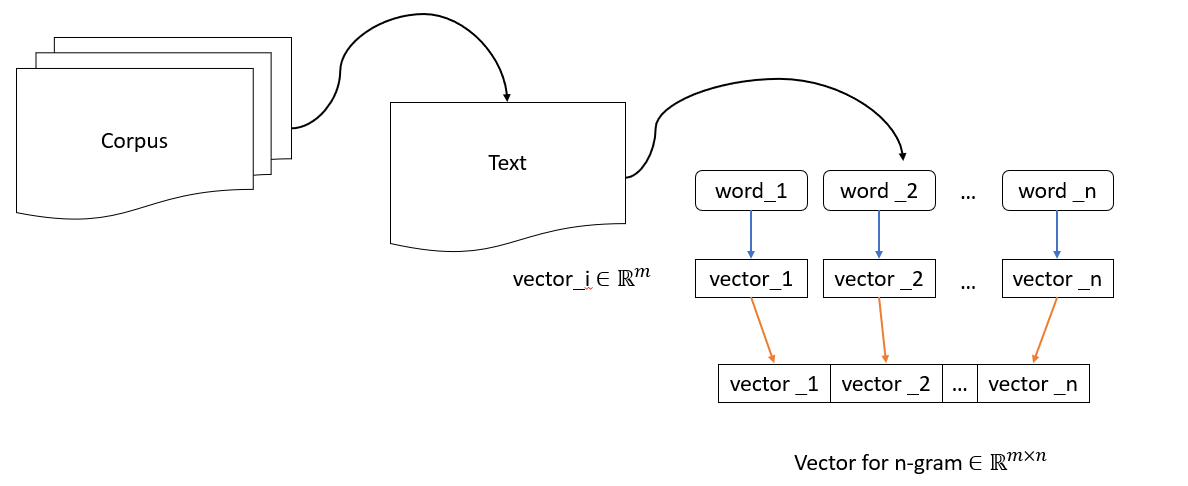

In [ ]:
def convert_text_to_vector(text, dictionary, n, m):
  #split the text into words
  text = text.strip().split()
  #It is the list for all the vectors in text
  text_vectors = []

  #inspect all n-grams in the text
  for i in range(len(text) - n + 1):
      #The list of vectors for words in the n-gram
      gram_vec = []
      #Let's look into every word of the n-gram
      for word in text[i:i+n]:
        #If current word is not in dictionary, we skip this n-gram
        if word not in dictionary:
          gram_vec = []
          break
        vec_ = dictionary[word][:m]
        gram_vec.append(vec_)

      #If the list of vectors is not correct, we skip the n-gram
      if len(gram_vec) != n or len(gram_vec[-1]) != m:
        continue

      text_vectors.append(np.array(gram_vec).flatten())
  return text_vectors


In [ ]:
#How long is the n-gram
n = 2
#How long is a vector for every word
m = 1

convert_text_to_vector('parrot think and say hello hello', dictionary, n, m)

[array([-0.45814364, -0.37627136]),
 array([-0.45814364, -0.69686009]),
 array([-0.69686009, -0.69686009])]

The resulting 2-grams are 'parrot think', 'think and', 'and say', 'say hello', 'hello hello'.

However, 'and' is not in our dictionary, so we do not use any 2-grams which contain this word. He have 3 2-grams:'parrot think',  'say hello', 'hello hello'

For every word we take vector of size 1:

In [ ]:
for word in ['parrot', 'think', 'say', 'hello']:
  print(word, dictionary[word][:1])

parrot [-0.45814364]
think [-0.37627136]
say [-0.45814364]
hello [-0.69686009]


Easy to see, that the n-gramms are created using vectors of corresponding words from the n-gram

Now, you can create the vectors for n-gramms from any text.



And the same for russian (let's create a dataset for the text `russian_texts/friend.txt`)

In [ ]:
n_russian = 3
m_russian = 1

text_russian = open('/content/russian_texts/friend.txt', 'r').read()
convert_text_to_vector(text_russian, dictionary_russian, n_russian, m_russian)

[array([-0.17446661, -0.17446661, -0.0872333 ]),
 array([-0.17446661, -0.0872333 , -0.0872333 ]),
 array([-0.0872333 , -0.0872333 , -0.37026002]),
 array([-0.0872333 , -0.37026002, -0.34893321]),
 array([-0.37026002, -0.34893321, -0.17446661]),
 array([-0.34893321, -0.17446661, -0.37026002]),
 array([-0.17446661, -0.37026002, -0.34893321]),
 array([-0.37026002, -0.34893321, -0.0872333 ]),
 array([-0.34893321, -0.0872333 , -0.0872333 ]),
 array([-0.0872333, -0.0872333, -0.0872333]),
 array([-0.0872333 , -0.0872333 , -0.17446661]),
 array([-0.0872333 , -0.17446661, -0.0872333 ]),
 array([-0.17446661, -0.0872333 , -0.34893321]),
 array([-0.0872333 , -0.34893321, -0.0872333 ]),
 array([-0.34893321, -0.0872333 , -0.0872333 ]),
 array([-0.0872333 , -0.0872333 , -0.47441979]),
 array([-0.0872333 , -0.47441979, -0.0872333 ]),
 array([-0.47441979, -0.0872333 , -0.0872333 ]),
 array([-0.0872333, -0.0872333, -0.0872333]),
 array([-0.0872333 , -0.0872333 , -0.17446661]),
 array([-0.0872333 , -0.17

The next step depends on your task. You can apply this function to the whole corpora (open the corpors file and pass each line to the function) or to several texts.